APROACH #5

TEST MODEL

In [2]:
import pandas as pd 
import math
import random
import matplotlib.pyplot as plt 
import numpy as np
from PIL import Image

In [7]:
def generateCitizen(orgX,orgY,maxDis):
    
    dis = random.uniform(-maxDis,maxDis) 
    perOfDis = random.uniform(0,1)
    dis = dis * perOfDis
    direction = math.radians(random.randint(0,360)) 
    xTemp = orgX + math.cos(direction) * dis
    yTemp = orgY + math.sin(direction) * dis
    return (round(xTemp),round(yTemp))

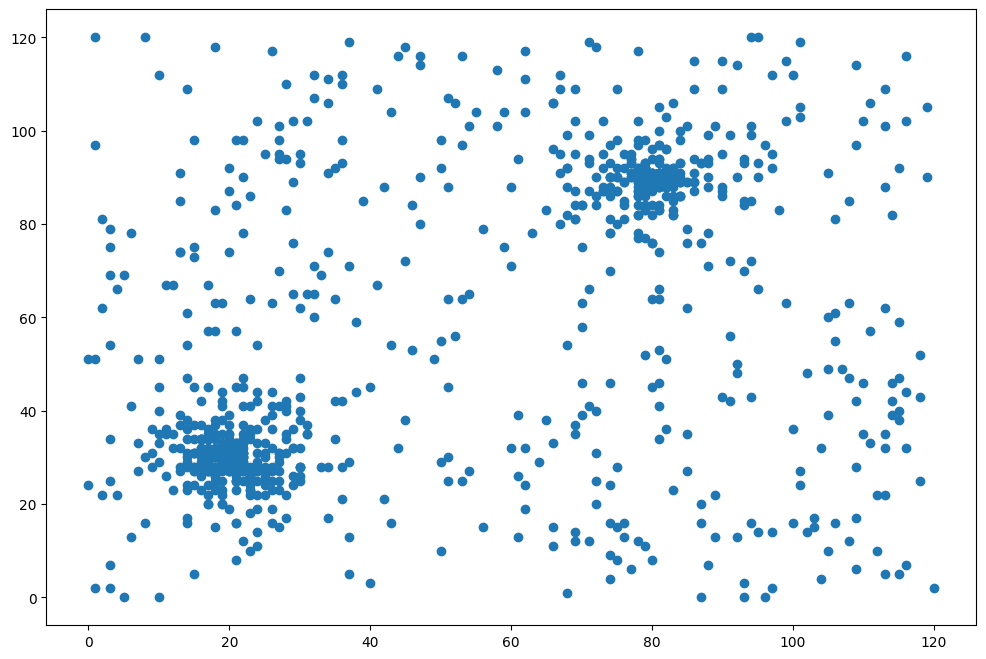

In [8]:
populationMap = pd.DataFrame()
x= []
y= []
for i in range(350):
    pos = generateCitizen(20,30,20)
    x.append(pos[0])
    y.append(pos[1])
for i in range(250):
    pos = generateCitizen(80,90,20)
    x.append(pos[0])
    y.append(pos[1])
for i in range(400):
    x.append(random.randint(0,120))
    y.append(random.randint(0,120))
populationMap["X"] = x
populationMap["Y"] = y
plt.figure(figsize = (12,8))
plot = plt.scatter(data = populationMap, x = "X", y = "Y")

OWNERSHIP DEMONSTRATION

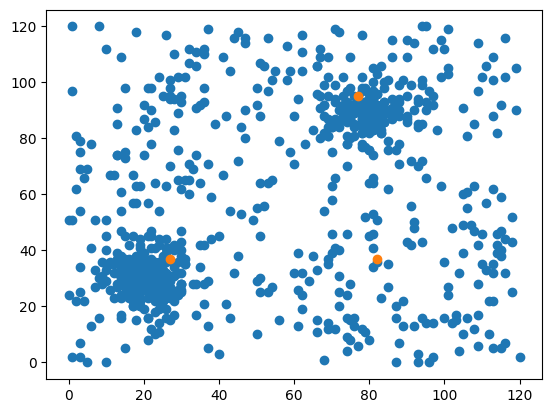

In [9]:
districts = 3
districtMap = pd.DataFrame(columns = ("X","Y"))
for i in range(districts):
    districtMap.loc[len(districtMap)] = [random.randint(0,100),random.randint(0,100)]
plt.scatter(data = populationMap, x = "X",y = "Y")
plt.scatter(data = districtMap, x = "X",y = "Y")

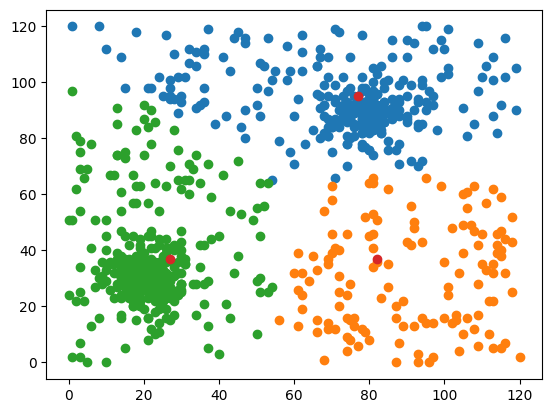

In [10]:
def findDistance(perX,perY,cenX,cenY):
    return abs(math.sqrt((cenX - perX) ** 2 + (cenY - perY) ** 2))
    
results = []

for w in range(len(districtMap)):
    results.append([[],[]])
    
for i in range(len(populationMap["X"])):
    pointXVal = populationMap["X"][i]
    pointYVal = populationMap["Y"][i]
    assignedPoint = None
    distance = None
    position = None
    currentPoint = 0
    for e in districtMap.iterrows(): 
        popXVal = e[1]["X"]
        popYVal = e[1]["Y"]
        currDistance = findDistance(pointXVal,pointYVal,popXVal,popYVal)
        if assignedPoint == None:
            assignedPoint = e[0]
            distance = currDistance
            position = pos
        else:
            if currDistance < distance:
                assignedPoint = e[0]
                distance = currDistance
                position = pos
        currentPoint += 1
    results[assignedPoint - 1][0].append(pointXVal)
    results[assignedPoint - 1][1].append(pointYVal)
    
finalResults = []
for i in results:
    temp = pd.DataFrame()
    temp["X"] = i[0]
    temp["Y"] = i[1]
    finalResults.append(temp)
    plt.scatter(data = temp,x = "X",y = "Y")
plt.scatter(data = districtMap, x = "X",y = "Y")
    

DISTRICT POSITION

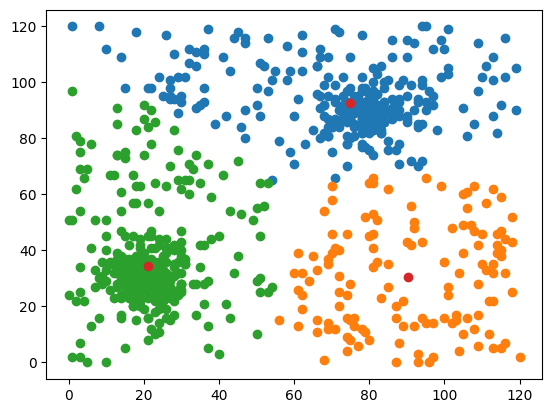

In [11]:
districtMap["X"] = districtMap["X"].astype('float64')
districtMap["Y"] = districtMap["Y"].astype('float64')
for x,district in enumerate(finalResults):
    tempX = np.mean(district["X"])
    tempY = np.mean(district["Y"])
    districtMap.loc[x] = [tempX,tempY]
    plt.scatter(data = district,x = "X",y = "Y")
plt.scatter(data = districtMap,x = "X",y = "Y")

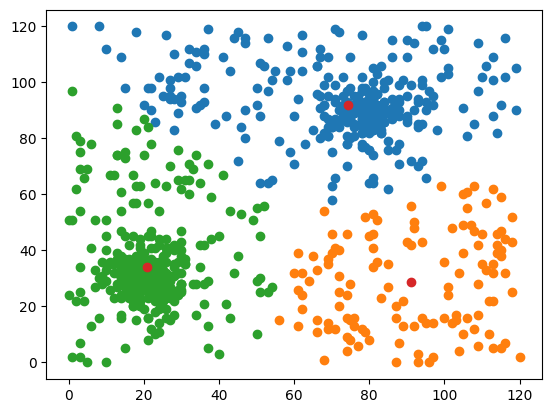

In [12]:
districts = 3
epochs = 10
for w in range(epochs):
    mapPoints = []
    for i in range(districts):
        mapPoints.append([[],[]])
    for e in range(len(populationMap["X"])):
        pos = (populationMap["X"][e],populationMap["Y"][e])
        assignedPoint = None
        distance = None
        position = None
        for i in range(districtMap.shape[0]):
            pointPos = (districtMap.loc[i]["X"],districtMap.loc[i]["Y"])
            currDistance  = findDistance(pointPos[0],pointPos[1],pos[0],pos[1])
            if assignedPoint == None:
                assignedPoint = i
                distance = currDistance
                position = pos
            else:
                if currDistance < distance:
                    assignedPoint = i
                    distance = currDistance
                    position = pos
        mapPoints[assignedPoint][0].append(position[0])
        mapPoints[assignedPoint][1].append(position[1])
    for i in range(districtMap.shape[0]):
        tempX = np.mean(mapPoints[i][0])
        tempY = np.mean(mapPoints[i][1])
        districtMap.loc[i] = [tempX,tempY]
for i in mapPoints:
    plt.scatter(x = i[0],y =i[1])
plt.scatter(data = districtMap,x = "X",y = "Y")

INEQUALITY

District 1: 408K people
District 2: 124K people
District 3: 468K people


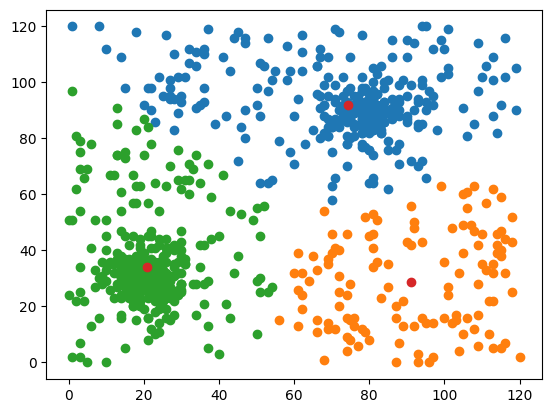

In [13]:
for x,i in enumerate(mapPoints):
    print("District " + str(x+1) + ": " + str(len(i[0])) + "K people")
    plt.scatter(x = i[0],y =i[1])
plt.scatter(data = districtMap,x = "X",y = "Y")

COST

Text(0.5, 1.0, 'Cost: 0.29')

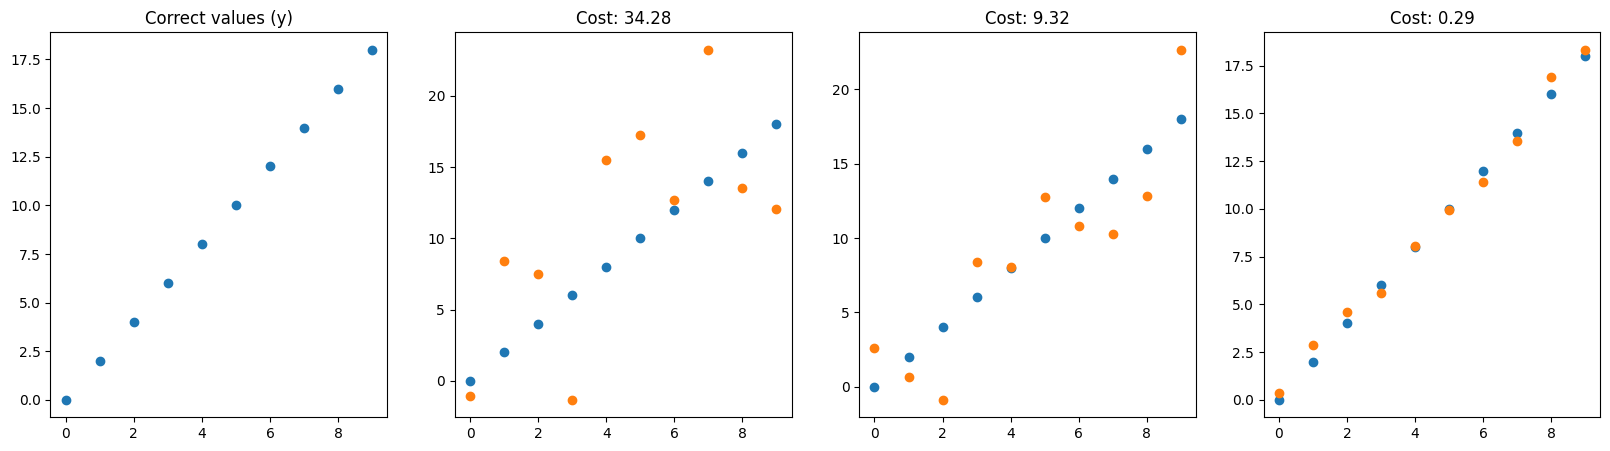

In [14]:
List1 = pd.DataFrame(columns = ("X","Y"))
List2 = pd.DataFrame(columns = ("X","Y"))
List3 = pd.DataFrame(columns = ("X","Y"))
YList = pd.DataFrame(columns = ("X","Y"))

def findCost(YList,UHCList):
    totalCost = 0
    m = UHCList.shape[0]
    for i in range(m):
        fOfx = UHCList.loc[i]["Y"]
        y = YList.loc[i]["Y"]
        totalCost += (fOfx -y) ** 2
    avgCost = totalCost / m
    return round(avgCost * 100)/100
for i in range(10):
    YList.loc[len(YList)] = [i,i * 2]
    List1.loc[len(List1)] = [i,i * 2 + random.uniform(-10,10)]
    List2.loc[len(List2)] = [i,i * 2 + random.uniform(-5,5)]
    List3.loc[len(List3)] = [i,i * 2 + random.uniform(-1,1)]
    
YList.set_index("X",inplace = True)
List1.set_index("X",inplace = True)
List2.set_index("X",inplace = True)
List3.set_index("X",inplace = True)

fig,ax = plt.subplots(1,4,figsize = (20,5))
ax[0].scatter(data = YList.reset_index(),x = "X",y = "Y")
ax[0].set_title("Correct values (y)")

ax[1].scatter(data = YList.reset_index(),x = "X",y = "Y")
ax[1].scatter(data = List1.reset_index(),x = "X",y = "Y")
ax[1].set_title("Cost: " + str(findCost(YList,List1)))

ax[2].scatter(data = YList.reset_index(),x = "X",y = "Y")
ax[2].scatter(data = List2.reset_index(),x = "X",y = "Y")
ax[2].set_title("Cost: " + str(findCost(YList,List2)))

ax[3].scatter(data = YList.reset_index(),x = "X",y = "Y")
ax[3].scatter(data = List3.reset_index(),x = "X",y = "Y")
ax[3].set_title("Cost: " + str(findCost(YList,List3)))

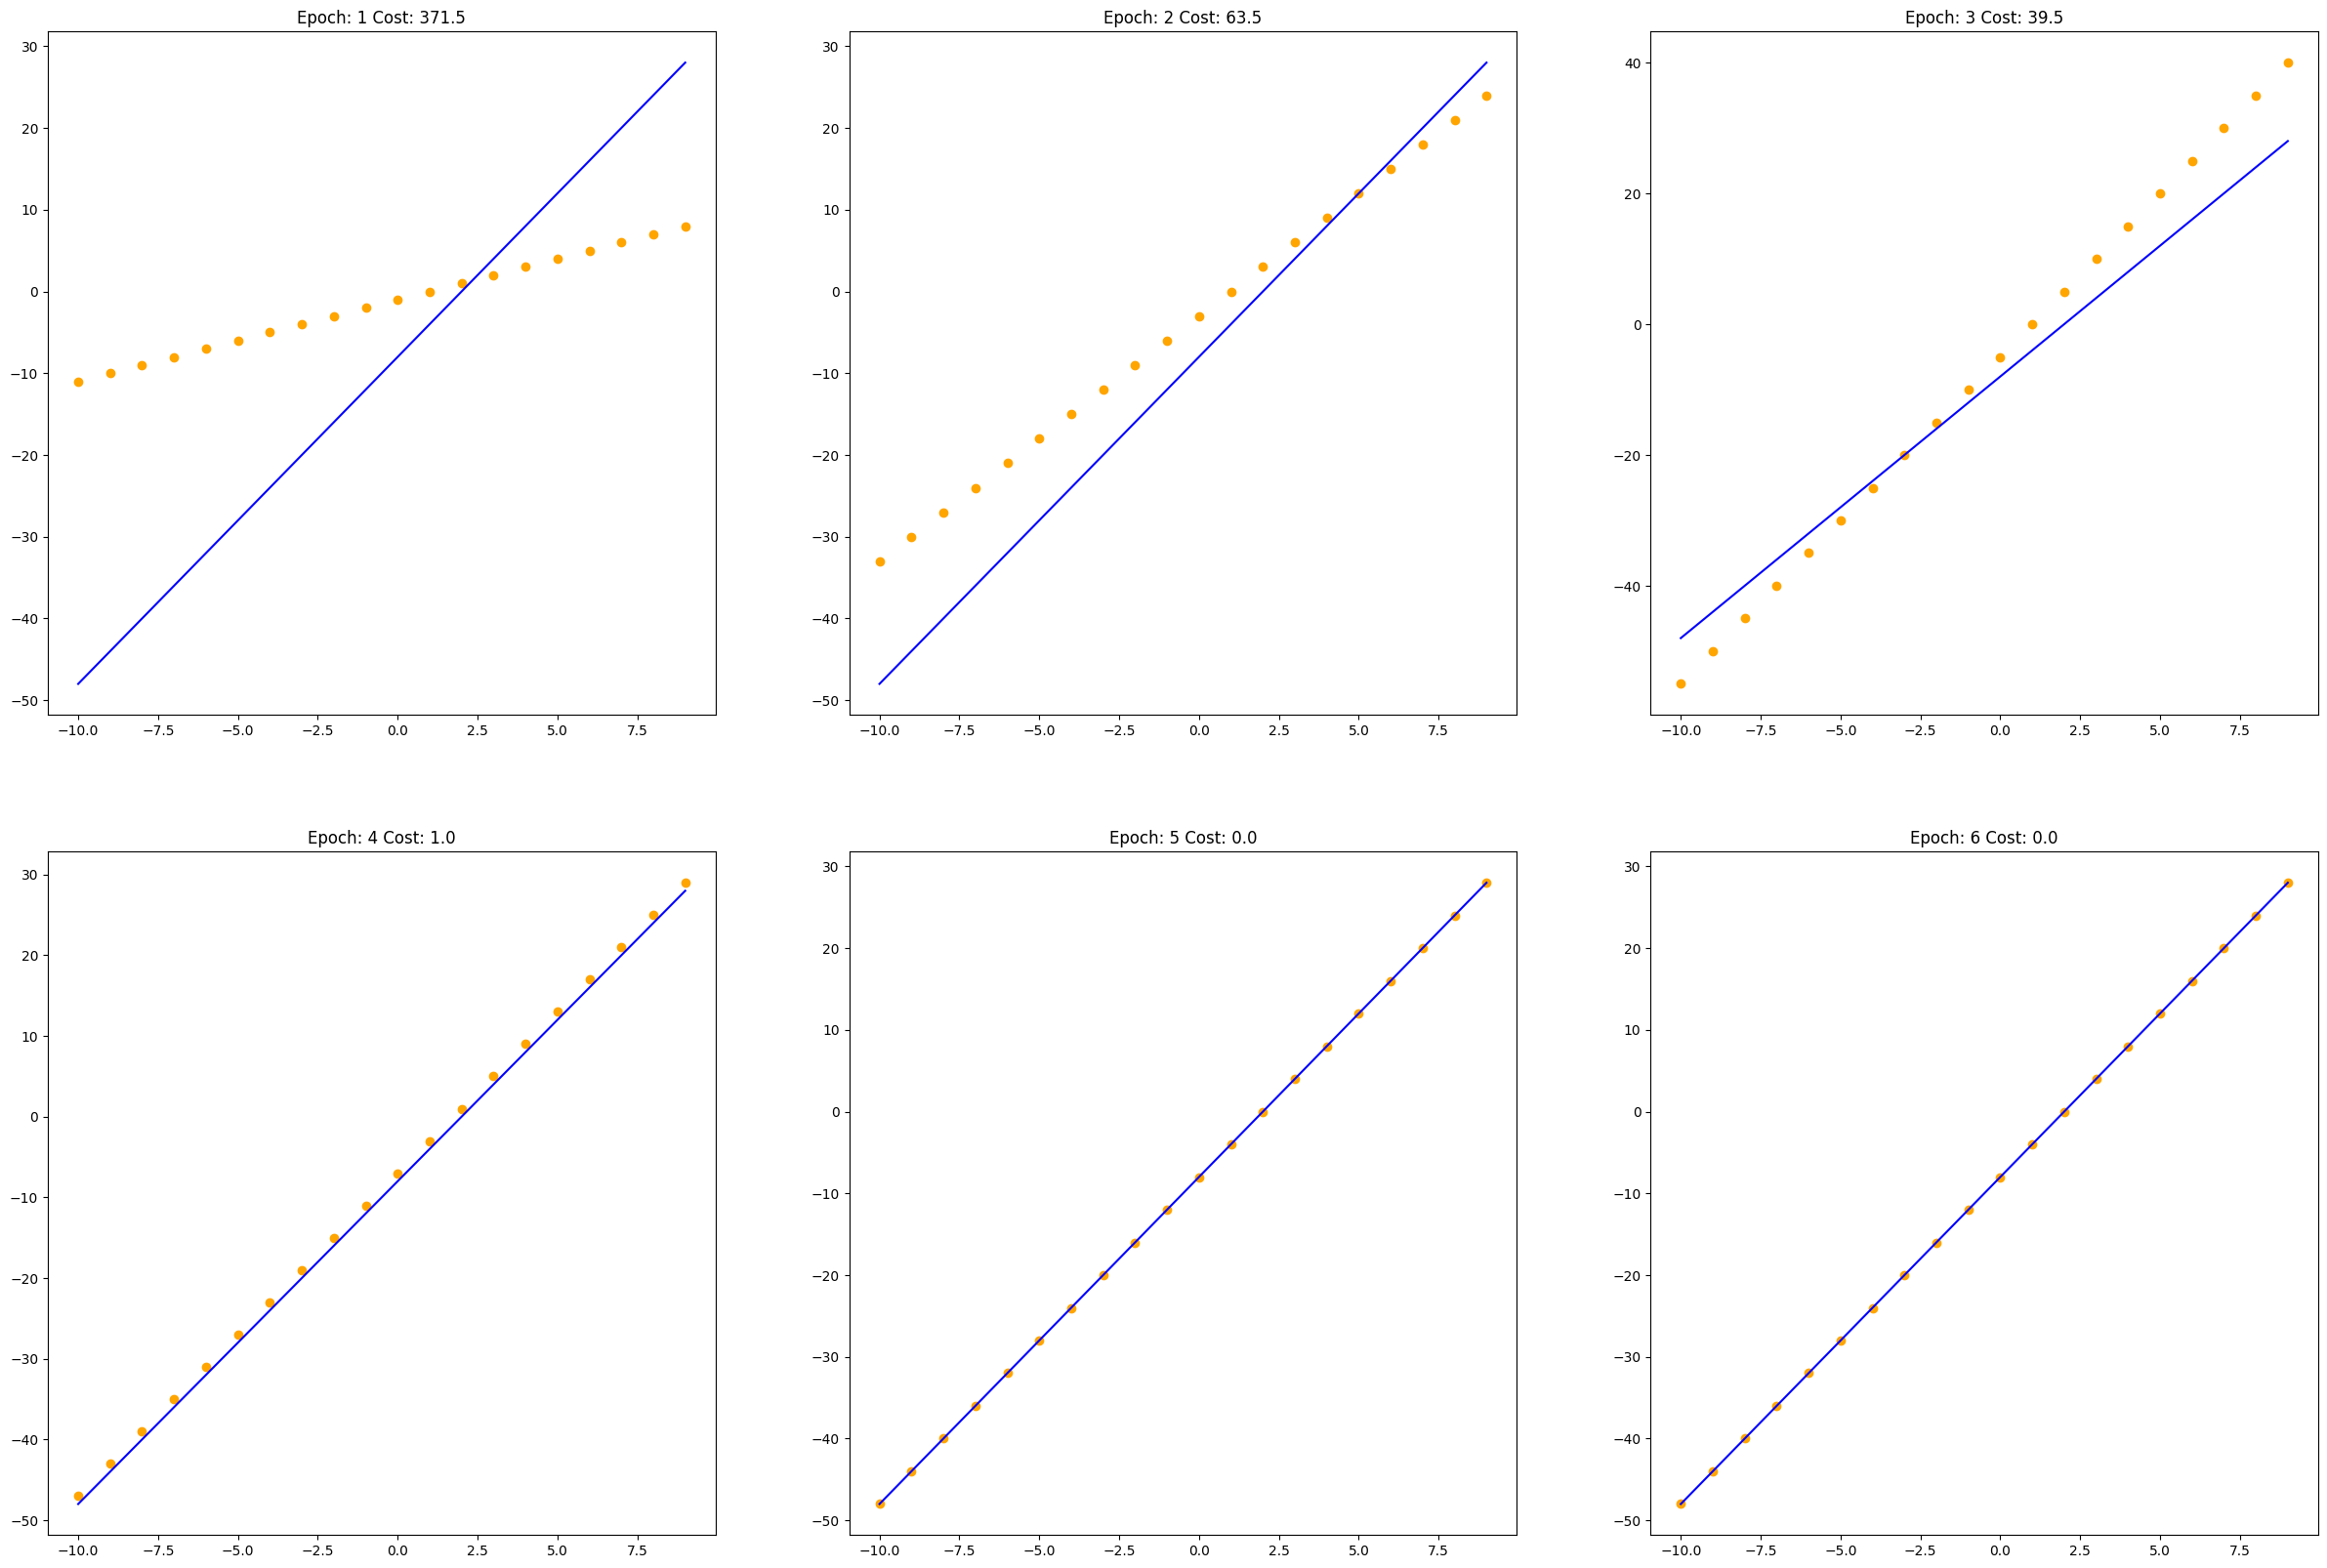

In [15]:
def computeCost(Y, UHCY):
    total = 0
    for i in range(Y.shape[0]):
        fOfx = UHCY.loc[i]["Y"]
        y = Y.loc[i]["Y"]
        total += (fOfx - y) ** 2
    avgCost=  total / Y.shape[0]
    return avgCost

def recompute(UHCSlope,UHCIntercept):
    UHCList = pd.DataFrame(columns = ("X","Y"))
    for e in range(20):
        UHCList.loc[len(UHCList)] = [e-10,UHCSlope * (e-10) + UHCIntercept]
    return UHCList
fig, ax = plt.subplots(2,3,figsize = (30,20))
plotOrder = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]
correctSlope = 4
correctIntercept = -8
YList = pd.DataFrame(columns = ("X","Y"))
for i in range(20):
    YList.loc[len(YList)] = [i-10,correctSlope * (i-10) + correctIntercept]
UHCSlope = 0
UHCIntercept = 0
for i in range(12):
    changeUHCSlope = 0
    changeUHCIntercept = 0
    currCost = computeCost(YList,recompute(UHCSlope,UHCIntercept))
    addCost = computeCost(YList,recompute(UHCSlope + .1, UHCIntercept))
    subCost = computeCost(YList,recompute(UHCSlope - .1, UHCIntercept))
    if(min([currCost,addCost,subCost]) == addCost):
        changeUHCSlope += 1
    elif(min([currCost,addCost,subCost]) == subCost):
        changeUHCSlope -= 1
    currCost = computeCost(YList,recompute(UHCSlope,UHCIntercept))
    addCost = computeCost(YList,recompute(UHCSlope, UHCIntercept + .1))
    subCost = computeCost(YList,recompute(UHCSlope, UHCIntercept - .1))
    if(min([currCost,addCost,subCost]) == subCost):
        changeUHCIntercept -= 1
    elif(min([currCost,addCost,subCost]) == addCost):
        changeUHCIntercept += 1
    UHCSlope += changeUHCSlope
    UHCIntercept += changeUHCIntercept
    if(i % 2 == 0):
        curr = recompute(UHCSlope, UHCIntercept)
        ax[plotOrder[int(i/2)]].scatter(curr["X"],curr["Y"],color = "orange")
        ax[plotOrder[int(i/2)]].plot(YList["X"],YList["Y"],color = "blue")
        ax[plotOrder[int(i/2)]].set_title("Epoch: " + str(i//2 + 1) + " Cost: " + str(computeCost(YList,curr)))

District 1: 408 error: 22.52%
District 2: 124 error: -62.76%
District 3: 468 error: 40.54%


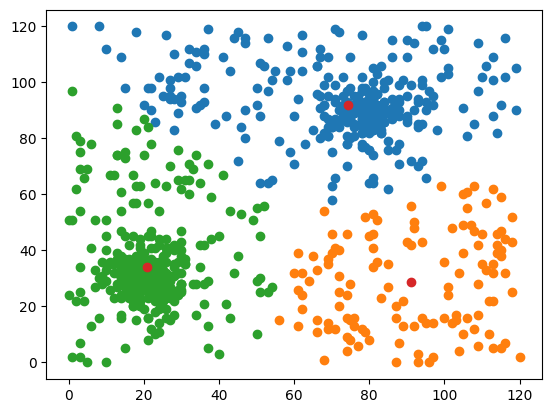

In [16]:
optimalPopulation  = round(populationMap.shape[0] / districtMap.shape[0])
for x,i in enumerate(mapPoints):
    err = round(((len(i[0]) - optimalPopulation)/optimalPopulation) * 10000)/100
    print("District " + str(x+1) + ": " + str(len(i[0])) + " error: " + str(err) + "%")
    plt.scatter(x = i[0],y =i[1])
plt.scatter(data = districtMap,x = "X",y = "Y")

In [17]:
def findDistance(perX,perY,cenX,cenY):
    return abs(math.sqrt((cenX - perX) ** 2 + (cenY - perY) ** 2))
    return None   
def reComputePop(populationMap,centerPos):
    results = []
    for w in range(len(centerPos)):
        results.append([[],[]])
    for i in range(len(populationMap["X"])):
        pointXVal = populationMap["X"][i]
        pointYVal = populationMap["Y"][i]
        assignedPoint = None
        distance = None
        position = None
        currentPoint = 0
        for e in centerPos.iterrows():
            popXVal = e[1]["X"]
            popYVal = e[1]["Y"]
            popWeightVal = e[1]["weights"]
            currDistance = findDistance(pointXVal,pointYVal,popXVal,popYVal) * popWeightVal
            if assignedPoint == None:
                assignedPoint = e[0]
                distance = currDistance
                position = pos
            else:
                if currDistance < distance:
                    assignedPoint = e[0]
                    distance = currDistance
                    position = pos
            currentPoint += 1
        results[assignedPoint -1][0].append(pointXVal)
        results[assignedPoint - 1][1].append(pointYVal)
    finalResults = []
    for i in results:
        temp = pd.DataFrame()
        temp["X"] = i[0]
        temp["Y"] = i[1]
        finalResults.append(temp)
    return finalResults
def findCost(populationMap,perfectPop):
    ans = 0
    for i in populationMap:
        if i.shape[0] - perfectPop < 0:
            ans += (perfectPop - i.shape[0]) *2
        else:
            ans += i.shape[0] - perfectPop
    return ans
def showState(totalPop, nodes,currentState,perfectPop):
    plt.scatter(data = totalPop,x = "X",y ="Y",color = "black")
    for i in currentState:
        plt.scatter(data = i,x = "X",y = "Y")
    plt.scatter(data=  nodes, x = "X",y = "Y", color = "grey")
    print("cost: " + str(findCost(currentState,perfectPop)))

Text(0.5, 1.0, 'North District Weighted .7')

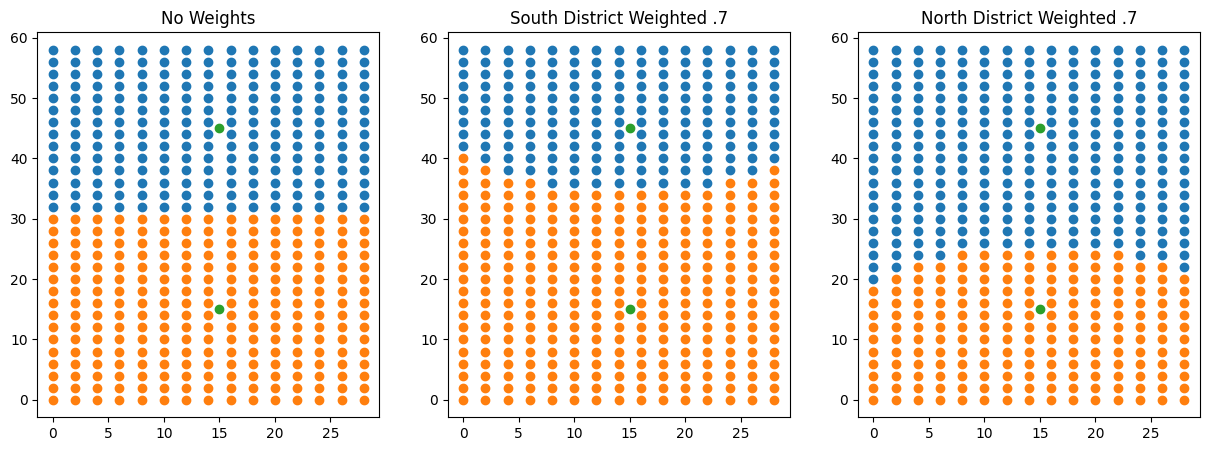

In [18]:
weightExample = pd.DataFrame(columns = ("X","Y"))
nodeExample = pd.DataFrame({"X":[15,15],"Y":[15,45],"weights":[1,1]})
for x in range(15):
    for y in range(30):
        weightExample.loc[len(weightExample)] = [x*2,y*2]
fig, ax = plt.subplots(1,3,figsize = (15,5))
results = reComputePop(weightExample,nodeExample)
for i in results:
    ax[0].scatter(data = i,x = "X",y = "Y")
ax[0].scatter(data= nodeExample,x = "X",y = "Y")
ax[0].set_title("No Weights")
nodeExample["weights"] = [.7,1.3]
results = reComputePop(weightExample,nodeExample)
for i in results:
    ax[1].scatter(data = i,x = "X",y = "Y")
ax[1].scatter(data= nodeExample,x = "X",y = "Y")
ax[1].set_title("South District Weighted .7")
nodeExample["weights"] = [1.3,.7]
results = reComputePop(weightExample,nodeExample)
for i in results:
    ax[2].scatter(data = i,x = "X",y = "Y")
ax[2].scatter(data= nodeExample,x = "X",y = "Y")
ax[2].set_title("North District Weighted .7")

FINAL PRODUCT

Epoch:100
Learn Rate: 0.078125
Position and Weights:
           X           Y   weights
0  76.794118  100.781863  1.007812
1  60.991935   68.580645  1.012500
2 -29.059829   27.683761  1.018750

Current Cost: 1.9999999999999432

District 1: 333K people, with an error of: 0.0%
District 2: 334K people, with an error of: 0.3%
District 3: 333K people, with an error of: 0.0%


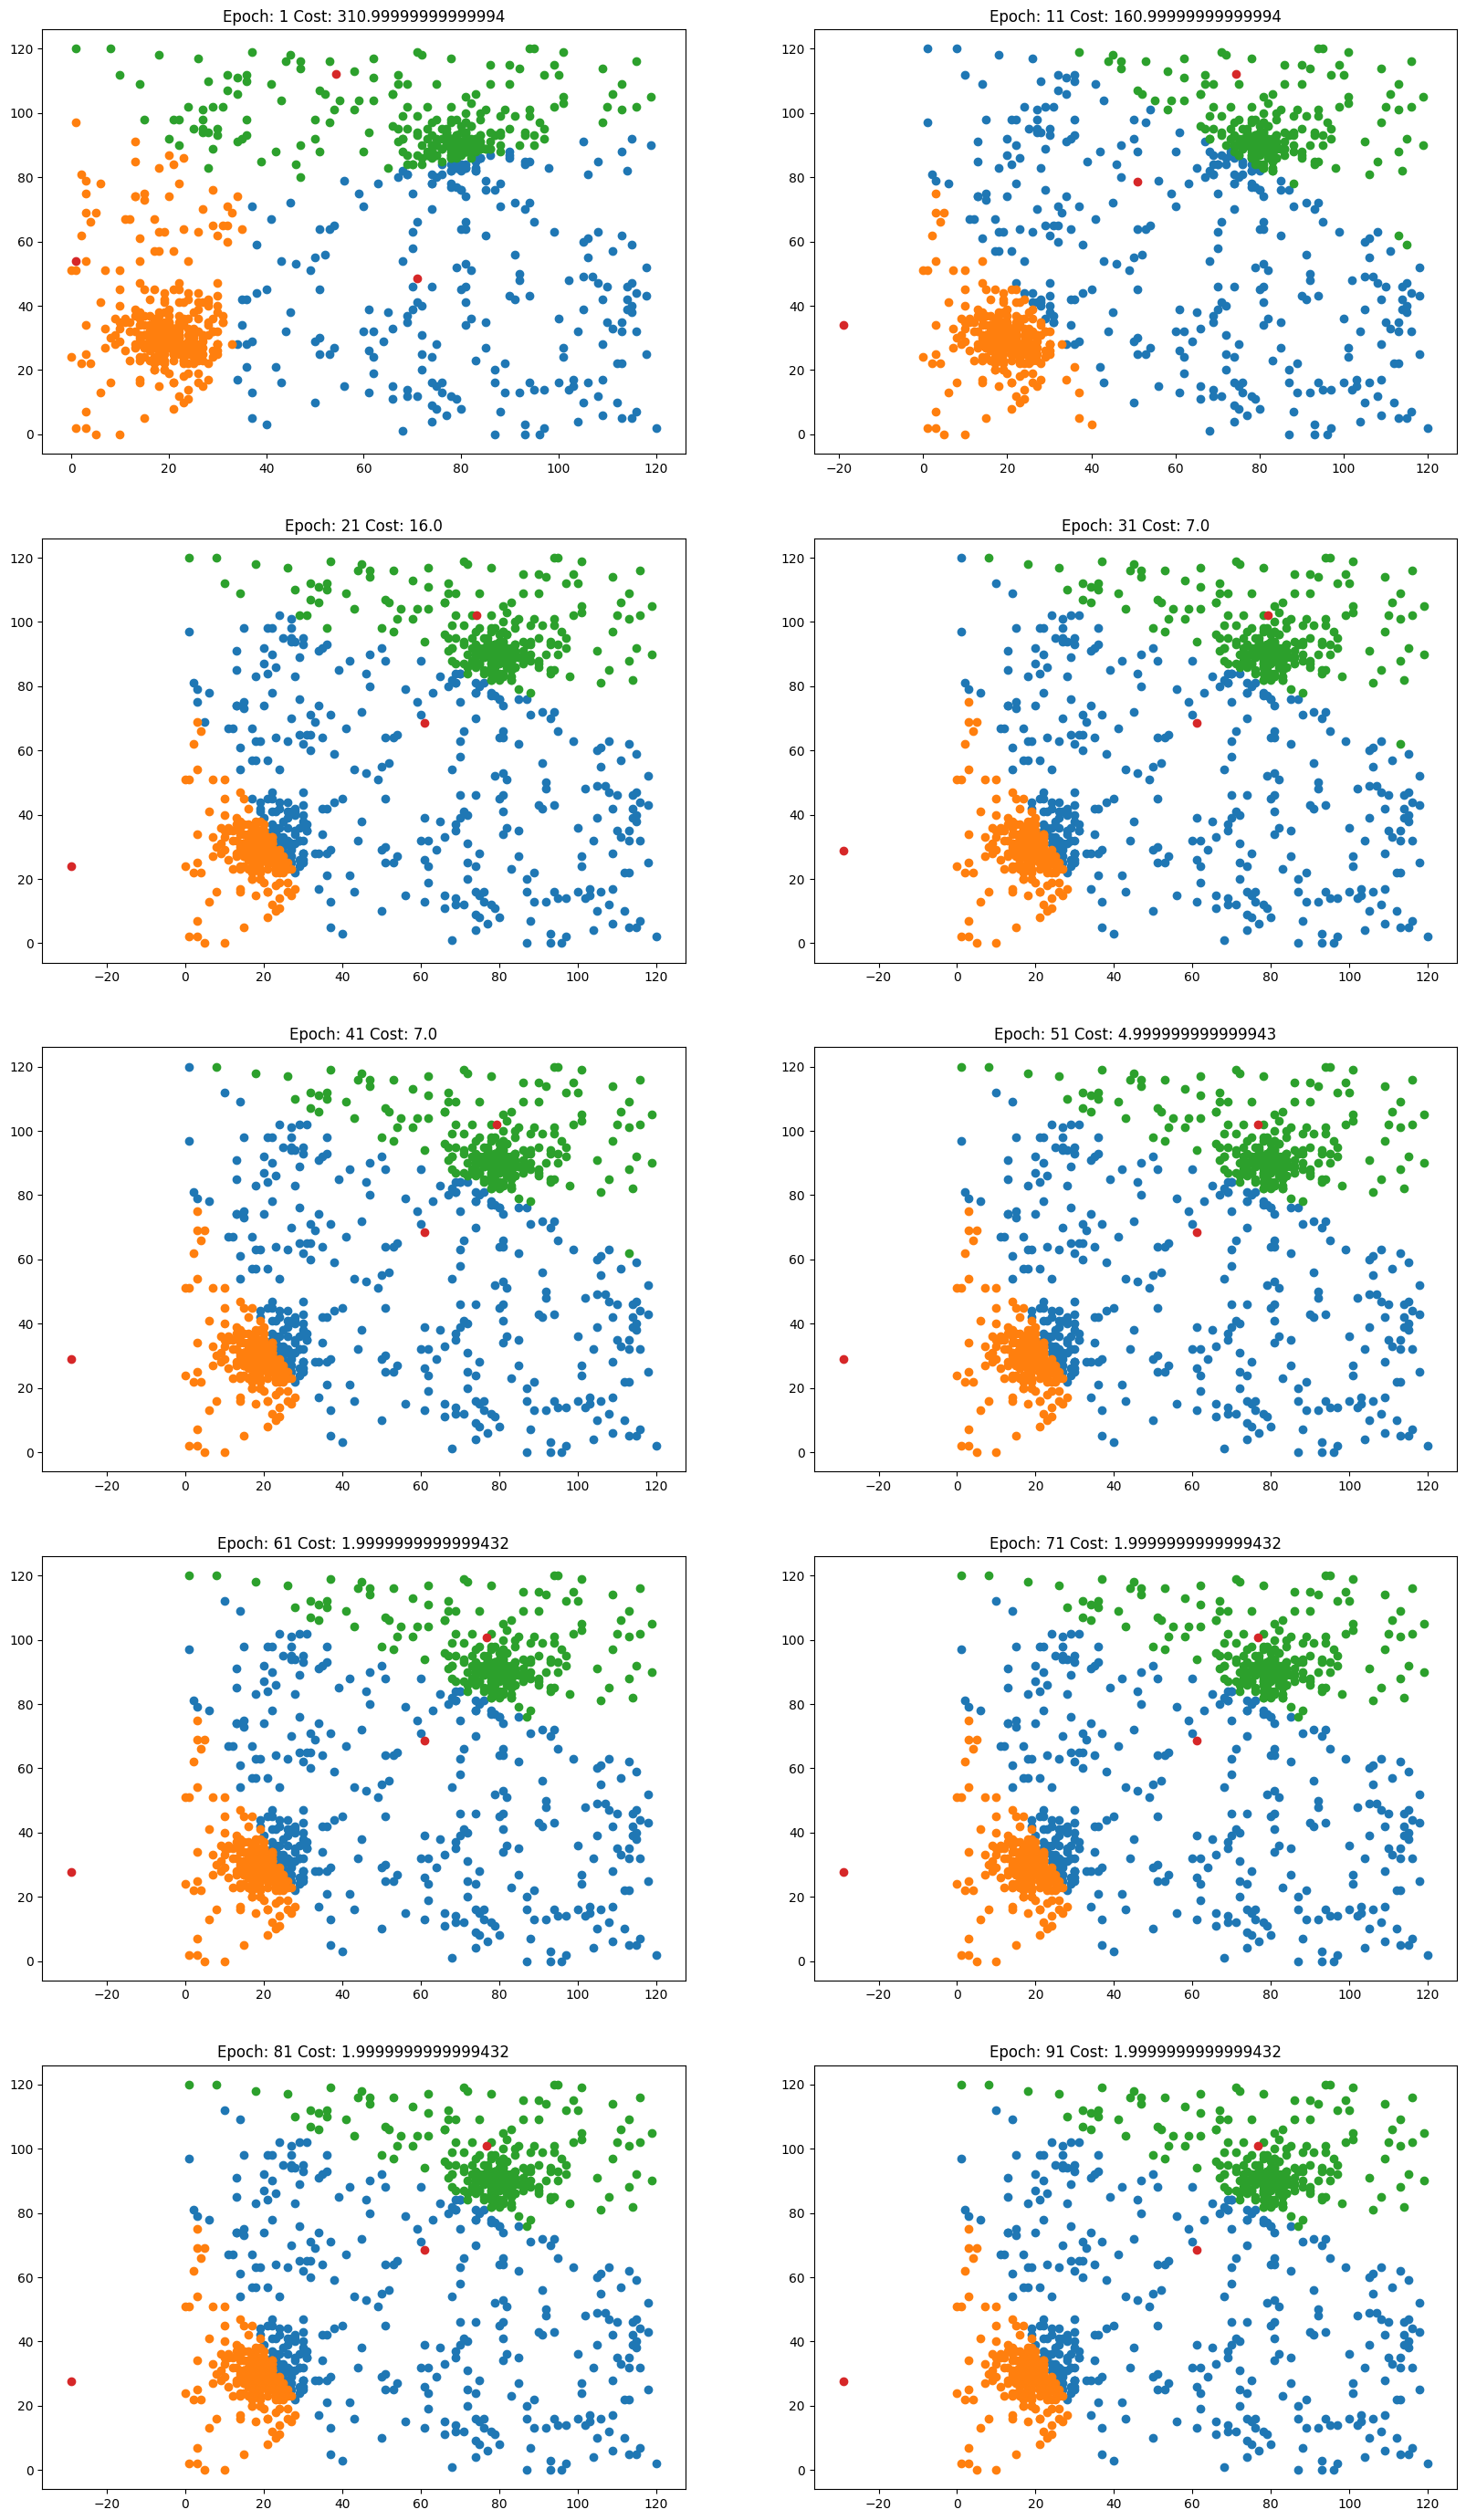

In [20]:
from IPython.display import display, clear_output
cost = []
districts = 3
epochs = 100
perfectPop = populationMap.shape[0] / districts 
learnRate = 10
lastMin = 0
fig, ax = plt.subplots(5,2,figsize = (20,35))
order = [[0,0],[0,1],[1,0],[1,1],[2,0],[2,1],[3,0],[3,1],[4,0],[4,1],[5,0],[5,1]]
districtNodes = districtMap
districtNodes["weights"] = [1] * districtMap.shape[0]
districtNodes["weights"] = districtNodes["weights"].astype('float64')
for i in range(epochs):
    ownership = reComputePop(populationMap,districtNodes)
    currCost = findCost(ownership,perfectPop)
    additionsDistrict = pd.DataFrame(columns = ["X","Y","weights"])
    additionsDistrict["weights"] = additionsDistrict["weights"].astype('float64')
    for e in districtNodes.iterrows():
        currRow = {"X":0,"Y":0,"weights":0}
        copyDistrictNodes = districtNodes.copy(deep = True)
        copyDistrictNodes.loc[e[0],"X"] = copyDistrictNodes.loc[e[0],"X"] - learnRate
        ownership = reComputePop(populationMap,copyDistrictNodes)
        minusCost = findCost(ownership,perfectPop)
        copyDistrictNodes = districtNodes.copy(deep = True)
        copyDistrictNodes.loc[e[0],"X"] = copyDistrictNodes.loc[e[0],"X"] + learnRate
        ownership = reComputePop(populationMap,copyDistrictNodes)
        plusCost = findCost(ownership,perfectPop)
        if min([currCost,minusCost,plusCost]) == currCost:
            currRow["X"] = 0
        elif min([currCost,minusCost,plusCost]) == plusCost:
            currRow["X"] = learnRate
        elif min([currCost,minusCost,plusCost]) == minusCost:
            currRow["X"] = -learnRate
        copyDistrictNodes = districtNodes.copy(deep = True)
        copyDistrictNodes.loc[e[0],"Y"] = copyDistrictNodes.loc[e[0],"Y"] - learnRate
        ownership = reComputePop(populationMap,copyDistrictNodes)
        minusCost = findCost(ownership,perfectPop)
        copyDistrictNodes = districtNodes.copy(deep = True)
        copyDistrictNodes.loc[e[0],"Y"] = copyDistrictNodes.loc[e[0],"Y"] + learnRate
        ownership = reComputePop(populationMap,copyDistrictNodes)
        plusCost = findCost(ownership,perfectPop)
        if min([currCost,minusCost,plusCost]) == currCost:
            currRow["Y"] = 0
        elif min([currCost,minusCost,plusCost]) == plusCost:
            currRow["Y"] = learnRate
        elif min([currCost,minusCost,plusCost]) == minusCost:
            currRow["Y"] = -learnRate
        copyDistrictNodes = districtNodes.copy(deep = True)
        copyDistrictNodes.loc[e[0],"weights"] = copyDistrictNodes.loc[e[0],"weights"] - (.05 * (learnRate / 10))
        ownership = reComputePop(populationMap,copyDistrictNodes)
        minusCost = findCost(ownership,perfectPop)
        copyDistrictNodes = districtNodes.copy(deep = True)
        copyDistrictNodes.loc[e[0],"weights"] = copyDistrictNodes.loc[e[0],"weights"] + (.05 * (learnRate / 10))
        ownership = reComputePop(populationMap,copyDistrictNodes)
        plusCost = findCost(ownership,perfectPop)
        if min([currCost,minusCost,plusCost]) == currCost:
            currRow["weights"] = currRow["weights"]
        elif min([currCost,minusCost,plusCost]) == plusCost:
            currRow["weights"] = currRow["weights"] + (.05 * (learnRate / 40))
        elif min([currCost,minusCost,plusCost]) == minusCost:
            currRow["weights"] = currRow["weights"] - (.05 * (learnRate / 40))
        additionsDistrict.loc[len(additionsDistrict)] = currRow
    for e in districtNodes.iterrows():
        districtNodes.loc[e[0],"X"] = districtNodes.loc[e[0],"X"] + additionsDistrict["X"][e[0]]
        districtNodes.loc[e[0],"Y"] = districtNodes.loc[e[0],"Y"] + additionsDistrict["Y"][e[0]]
        districtNodes.loc[e[0],"weights"] = districtNodes.loc[e[0],"weights"] + additionsDistrict["weights"][e[0]]
    ownership = reComputePop(populationMap,districtNodes)
    currCost = findCost(ownership,perfectPop)
    clear_output(wait=True)
    if len(cost) > 1 and min(cost) <= currCost:
        lastMin +=1
        if lastMin > 10:
            lastMin = 0
            learnRate /= 2
    else:
        lastMin = 0
    cost.append(currCost)
    print("Epoch:" + str(i + 1))
    print("Learn Rate: " + str(learnRate))
    print("Position and Weights:")
    print(districtNodes)
    print("\nCurrent Cost: " + str(currCost) + "\n")
    for x,e in enumerate(ownership):
        err = round(((e.shape[0] - optimalPopulation)/optimalPopulation) * 10000)/100
        print("District " + str(x+1) + ": " + str(e.shape[0]) + "K people, with an error of: " + str(err) + "%")
    if i % 10 == 0:
        currentGraph = (order[(i+1)//10][0],order[(i+1)//10][1])
        for e in ownership:
            ax[currentGraph].scatter(data = e,x = "X",y = "Y")
        ax[currentGraph].scatter(data= districtNodes,x= "X",y = "Y")
        ax[currentGraph].set_title("Epoch: " + str((i + 1)) + " Cost: " + str(currCost))

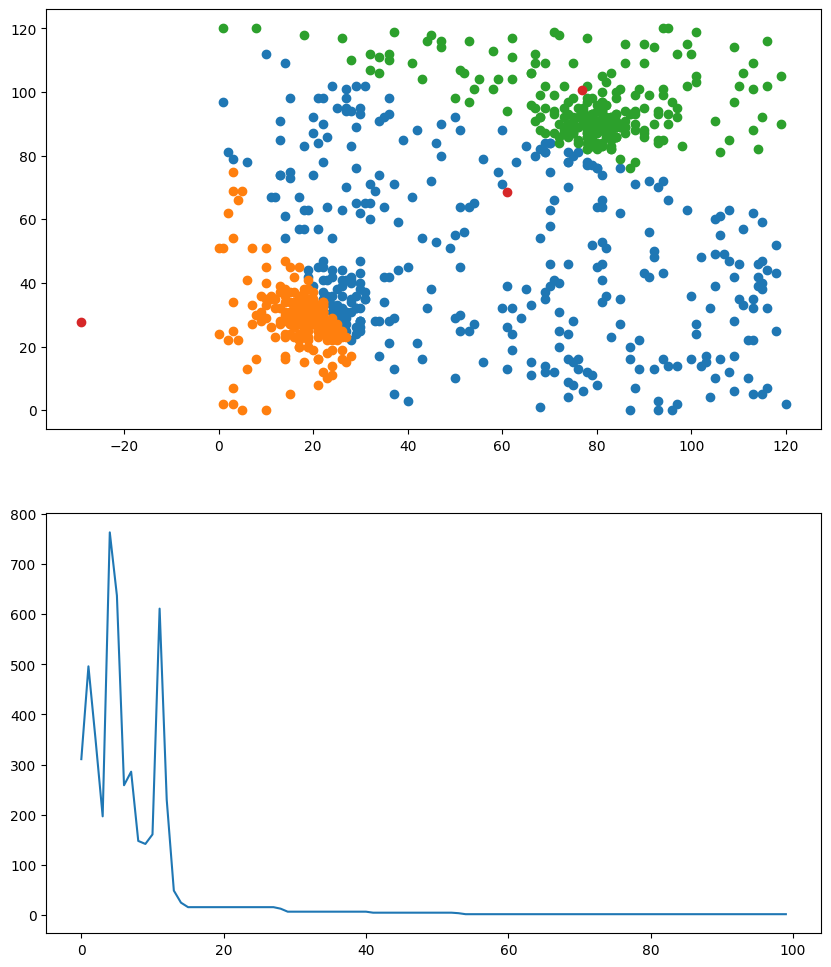

In [21]:
fig1,ax1 = plt.subplots(2,figsize = (10,12))
for e in ownership:
    ax1[0].scatter(data = e,x = "X",y = "Y")
ax1[0].scatter(data= districtNodes,x= "X",y = "Y")
ax1[1].plot(list(range(0,len(cost))),cost)

In [22]:
for x,i in enumerate(ownership):
    err = round(((i.shape[0] - optimalPopulation)/optimalPopulation) * 10000)/100
    print("District " + str(x+1) + ": " + str(i.shape[0]) + " error of: " + str(err) + "%")
print("\nOptimal population: " + str(optimalPopulation))

District 1: 333 error of: 0.0%
District 2: 334 error of: 0.3%
District 3: 333 error of: 0.0%

Optimal population: 333


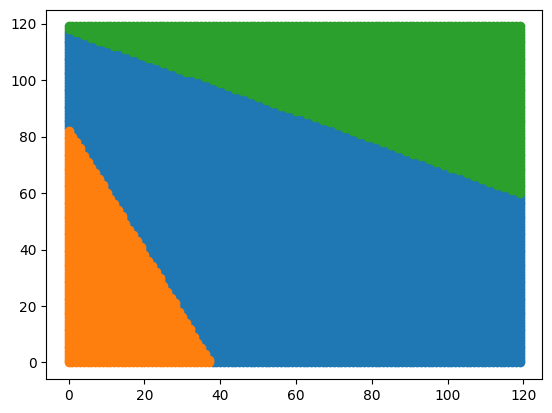

In [23]:
totalShape = pd.DataFrame(columns = ("X","Y"))
for i in range(120):
    for e in range(120):
        totalShape.loc[len(totalShape)] = [i,e]
ownership = reComputePop(totalShape,districtNodes)
for i in ownership:
    plt.scatter(data= i, x = "X",y = "Y")

TEST STATE

(np.float64(-0.5), np.float64(641.5), np.float64(631.5), np.float64(-0.5))

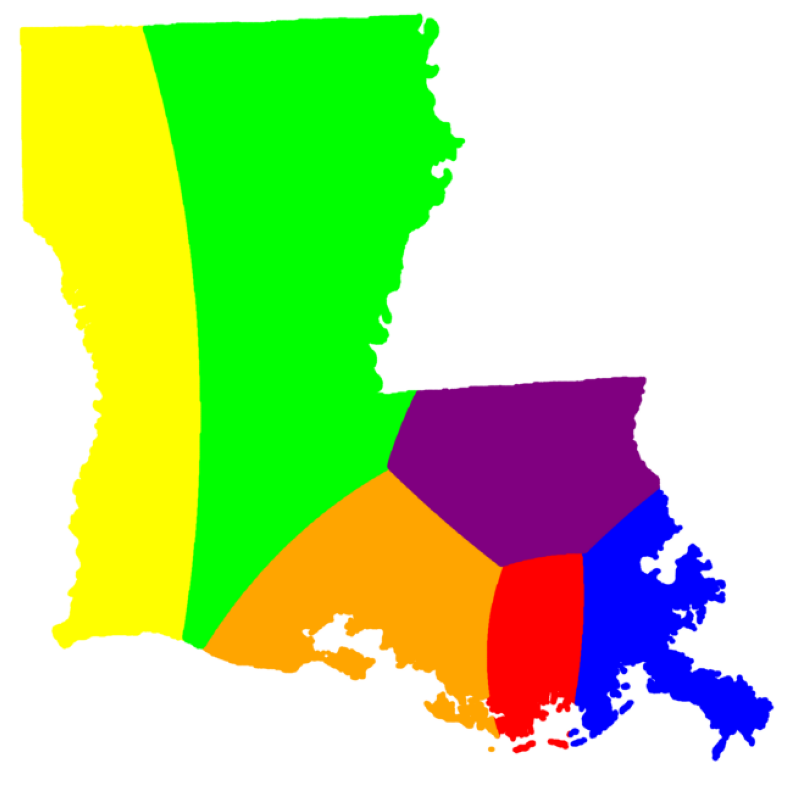

In [24]:
pic = Image.open("new.png")
fig,ax = plt.subplots(1,1,figsize = (15,10))
ax.imshow(pic)
ax.axis("off")

In [27]:
print("% error of population per district:\n")
districtPops = [1159,1157,1159,1159,1159,1158]
perfectPopulation = 1158.5
for x,i in enumerate(districtPops):
    err = round((perfectPopulation - i)/perfectPopulation * 1000000) / 10000
    print("District " + str(x+1) + ": " + str(err) + "%")

% error of population per district:

District 1: -0.0432%
District 2: 0.1295%
District 3: -0.0432%
District 4: -0.0432%
District 5: -0.0432%
District 6: 0.0432%


(np.float64(-0.5), np.float64(644.5), np.float64(571.5), np.float64(-0.5))

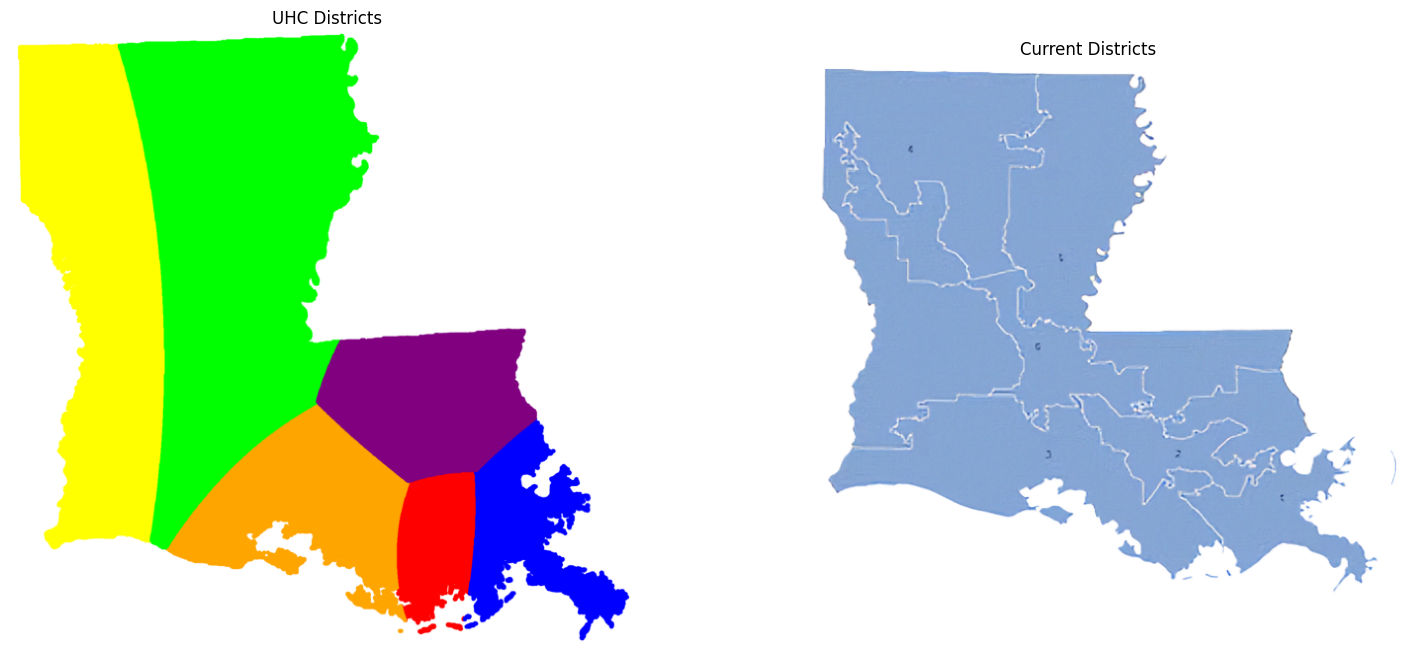

In [3]:
fig, ax = plt.subplots(1,2,figsize = (18,10))
genDistricts = Image.open("new.png")
realDistricts = Image.open("old.png")
ax[0].imshow(genDistricts)
ax[0].set_title("UHC Districts")
ax[0].axis("off")
ax[1].imshow(realDistricts)
ax[1].set_title("Current Districts")
ax[1].axis("off")

©UNETHICALHACKINGCLUB